### 1. Import Libraries

In [ ]:
!pip install datasets -q

In [ ]:
# ==========================================
# Task 1 : Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import KFold

import random
import time
import copy

### 2. Device Configuration and Reproducibility

In [ ]:
# ==========================================
# Task 1.1 : Device Configuration and Reproducibility
# ==========================================

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("DEVICE CONFIGURATION")
print("=" * 60)
print("Using device :", device)
if torch.cuda.is_available():
    print("GPU Name     :", torch.cuda.get_device_name(0))

DEVICE CONFIGURATION
Using device : cuda
GPU Name     : Tesla T4


### 3. Load and Prepare Oxford-IIIT Pet Dataset

MobileNetV2 is pretrained on ImageNet and therefore expects 224x224 RGB inputnormalized with the standard ImageNet channel-wise mean and standard deviation.The Oxford-IIIT Pet Dataset (37 breeds of cats and dogs) is loaded from theHugging Face Hub and every image is resized to 224x224 as part of the transformpipeline below.

In [ ]:
# ==========================================
# Task 2 : Load Oxford-IIIT Pet Dataset from Hugging Face Hub
# ==========================================

pet_dataset = load_dataset("timm/oxford-iiit-pet")

print("=" * 60)
print("OXFORD-IIIT PET DATASET LOADED FROM HUGGING FACE HUB")
print("=" * 60)
print(pet_dataset)
print("\nSample record keys:", pet_dataset["train"][0].keys())

README.md:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  378MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  413MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3680 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3669 [00:00<?, ? examples/s]

OXFORD-IIIT PET DATASET LOADED FROM HUGGING FACE HUB
DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'image_id', 'label_cat_dog'],
        num_rows: 3680
    })
    test: Dataset({
        features: ['image', 'label', 'image_id', 'label_cat_dog'],
        num_rows: 3669
    })
})

Sample record keys: dict_keys(['image', 'label', 'image_id', 'label_cat_dog'])


In [ ]:
# ==========================================
# Task 2.1 : Build Class List and Train/Val/Test Split
# ==========================================

# 'timm/oxford-iiit-pet' provides an official 'train' split (3,680 images) and
# 'test' split (3,669 images), each labelled with one of 37 breed classes.
train_val_split = pet_dataset["train"]
official_test_split = pet_dataset["test"]

label_feature = train_val_split.features["label"]
class_names = label_feature.names
num_classes = len(class_names)

print("Number of Breeds (Classes) :", num_classes)
print("Train+Val Images (official 'train' split) :", len(train_val_split))
print("Test Images (official 'test' split)        :", len(official_test_split))

# Carve a validation set out of the official training split (85 / 15),
# keeping the official test split completely untouched for final evaluation.
train_val_indices = list(range(len(train_val_split)))
random.Random(seed).shuffle(train_val_indices)

n_train_val = len(train_val_indices)
n_train = int(0.85 * n_train_val)

train_indices = train_val_indices[:n_train]
val_indices = train_val_indices[n_train:]
test_indices = list(range(len(official_test_split)))

print("\nTrain samples :", len(train_indices))
print("Val samples   :", len(val_indices))
print("Test samples  :", len(test_indices))

Number of Breeds (Classes) : 37
Train+Val Images (official 'train' split) : 3680
Test Images (official 'test' split)        : 3669

Train samples : 3128
Val samples   : 552
Test samples  : 3669


In [ ]:
# ==========================================
# Task 2.2 : Custom Dataset Class with Transform Pipeline
# ==========================================

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

class OxfordPetHFDataset(Dataset):
    def __init__(self, hf_split, indices, transform):
        self.hf_split = hf_split
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        real_index = self.indices[index]
        sample = self.hf_split[real_index]
        image = sample["image"].convert("RGB")
        label = sample["label"]
        image = self.transform(image)
        return image, label

train_dataset = OxfordPetHFDataset(train_val_split, train_indices, transform_pipeline)
val_dataset = OxfordPetHFDataset(train_val_split, val_indices, transform_pipeline)
test_dataset = OxfordPetHFDataset(official_test_split, test_indices, transform_pipeline)

sample_image, sample_label = train_dataset[0]

print("=" * 60)
print("DATASET WRAPPED IN CUSTOM PYTORCH DATASET")
print("=" * 60)
print("Training Samples      :", len(train_dataset))
print("Validation Samples    :", len(val_dataset))
print("Testing Samples       :", len(test_dataset))
print("Image Shape (resized) :", tuple(sample_image.shape))
print("Number of Classes     :", num_classes)

DATASET WRAPPED IN CUSTOM PYTORCH DATASET
Training Samples      : 3128
Validation Samples    : 552
Testing Samples       : 3669
Image Shape (resized) : (3, 224, 224)
Number of Classes     : 37


### 4. Display Sample Images

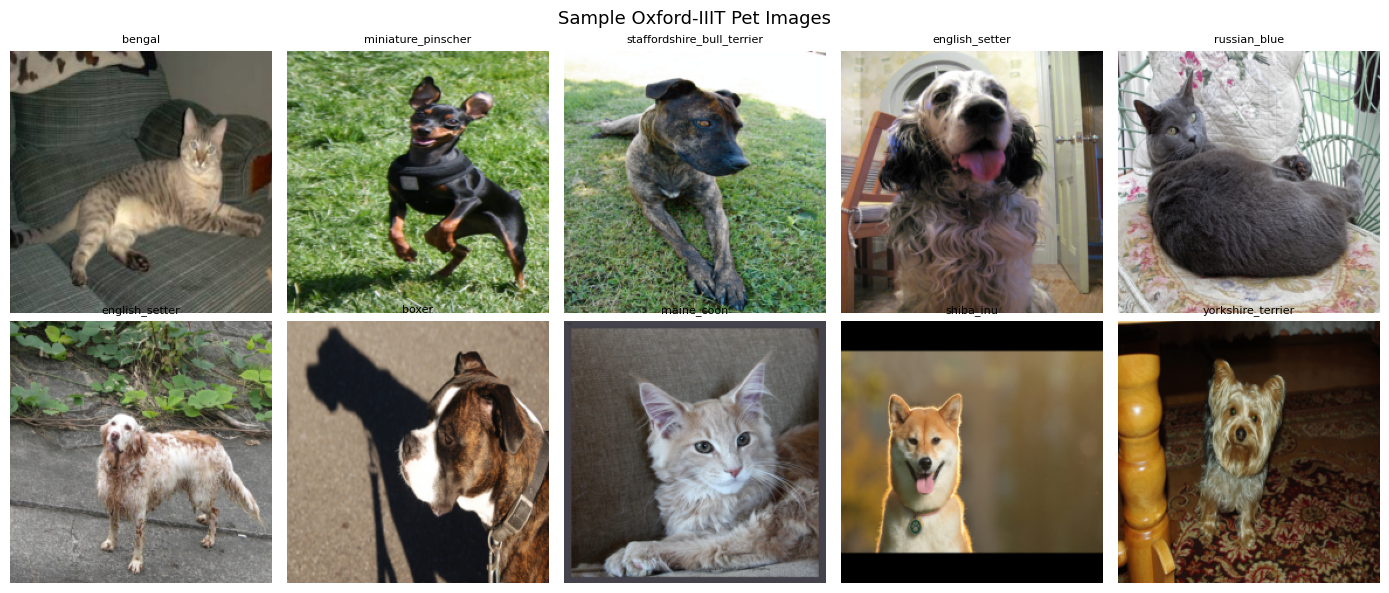

In [ ]:
# ==========================================
# Task 2.3 : Display Ten Sample Images
# ==========================================

def denormalize(tensor_image):
    image = tensor_image.clone().permute(1, 2, 0).numpy()
    image = image * np.array(imagenet_std) + np.array(imagenet_mean)
    image = np.clip(image, 0, 1)
    return image

plt.figure(figsize=(14, 6))

for index in range(10):
    image, label = train_dataset[index]
    image = denormalize(image)

    plt.subplot(2, 5, index + 1)
    plt.imshow(image)
    plt.title(class_names[label], fontsize=8)
    plt.axis("off")

plt.suptitle("Sample Oxford-IIIT Pet Images", fontsize=13)
plt.tight_layout()
plt.savefig("plot0_samples.png", dpi=300)
plt.show()

### 5. Fast-Study Subset

Sections 6 through 10 (weight initialization, regularization, batch normalization,optimizers and hyperparameter tuning) each require training several short models purelyto compare *relative* behaviour, not to produce the final model. To keep total runtimepractical, these individual studies use a smaller, fixed training/validation subset drawnfrom the training and validation splits above. The final transfer-learning, fine-tuning,cross-validation and test-evaluation stages (Sections 11 onward) use the full dataset.

In [ ]:
# ==========================================
# Task 2.4 : Fast-Study Subset for Sections 6-10
# ==========================================

study_train_size = 1200
study_val_size = 300

study_train_indices = random.Random(seed).sample(range(len(train_dataset)), study_train_size)
study_val_indices = random.Random(seed + 1).sample(range(len(val_dataset)), study_val_size)

study_train_dataset = Subset(train_dataset, study_train_indices)
study_val_dataset = Subset(val_dataset, study_val_indices)

study_batch_size = 32
study_train_loader = DataLoader(study_train_dataset, batch_size=study_batch_size, shuffle=True, num_workers=2)
study_val_loader = DataLoader(study_val_dataset, batch_size=study_batch_size, shuffle=False, num_workers=2)

print("=" * 60)
print("FAST-STUDY SUBSET")
print("=" * 60)
print("Study Train Samples :", len(study_train_dataset))
print("Study Val Samples   :", len(study_val_dataset))

FAST-STUDY SUBSET
Study Train Samples : 1200
Study Val Samples   : 300


### 6. MobileNetV2 Model Builder

In [ ]:
# ==========================================
# Task 3 : Helper Function to Build a MobileNetV2 Classifier
# ==========================================

def build_mobilenetv2(num_classes, pretrained=True, dropout_rate=0.2,
                       use_batchnorm=True, init_method=None, freeze_base=False):
    """
    Builds a MobileNetV2-based classifier.
    - pretrained     : load ImageNet weights
    - dropout_rate   : dropout probability in the classifier head
    - use_batchnorm  : whether the classifier head includes a BatchNorm1d layer
    - init_method    : None (use pretrained/default init) or one of
                        'zero', 'random', 'xavier', 'he' -- applied to the
                        classifier head's Linear layers
    - freeze_base    : if True, freezes all convolutional (feature) layers
    """
    weights = models.MobileNet_V2_Weights.IMAGENET1K_V2 if pretrained else None
    backbone = models.mobilenet_v2(weights=weights)

    in_features = backbone.last_channel  # 1280 for MobileNetV2

    head_layers = [nn.Linear(in_features, 256)]
    if use_batchnorm:
        head_layers.append(nn.BatchNorm1d(256))
    head_layers.append(nn.ReLU())
    head_layers.append(nn.Dropout(p=dropout_rate))
    head_layers.append(nn.Linear(256, num_classes))

    backbone.classifier = nn.Sequential(nn.Dropout(p=0.0), *head_layers)

    if freeze_base:
        for param in backbone.features.parameters():
            param.requires_grad = False

    def init_linear(layer):
        if isinstance(layer, nn.Linear):
            if init_method == "zero":
                nn.init.zeros_(layer.weight)
                nn.init.zeros_(layer.bias)
            elif init_method == "random":
                nn.init.normal_(layer.weight, mean=0.0, std=0.05)
                nn.init.zeros_(layer.bias)
            elif init_method == "xavier":
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
            elif init_method == "he":
                nn.init.kaiming_uniform_(layer.weight, nonlinearity="relu")
                nn.init.zeros_(layer.bias)

    if init_method is not None:
        backbone.classifier.apply(init_linear)

    return backbone.to(device)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate_model(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


print("MobileNetV2 builder and training helper functions defined.")

MobileNetV2 builder and training helper functions defined.


### 7. Weight Initialization Study (Section 5)

In [ ]:
# ==========================================
# Task 4 : Weight Initialization Comparison
# ==========================================

init_methods = ["zero", "random", "xavier", "he"]
init_epochs = 5

init_train_loss_history = {}
init_val_acc_history = {}

criterion = nn.CrossEntropyLoss()

print("=" * 60)
print("WEIGHT INITIALIZATION STUDY")
print("=" * 60)

for method in init_methods:
    print(f"\n--- Initialization: {method} ---")
    torch.manual_seed(seed)
    model = build_mobilenetv2(num_classes, pretrained=True, dropout_rate=0.2,
                               use_batchnorm=True, init_method=method, freeze_base=True)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    train_losses = []
    val_accs = []

    for epoch in range(init_epochs):
        train_loss, train_acc = train_one_epoch(model, study_train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate_model(model, study_val_loader, criterion)

        train_losses.append(train_loss)
        val_accs.append(val_acc)

        print(f"Epoch [{epoch + 1}/{init_epochs}]  Train Loss: {train_loss:.4f}  Val Acc: {val_acc:.4f}")

    init_train_loss_history[method] = train_losses
    init_val_acc_history[method] = val_accs

    del model
    torch.cuda.empty_cache()

print("\nWeight initialization study completed.")

WEIGHT INITIALIZATION STUDY

--- Initialization: zero ---
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 59.9MB/s]


Epoch [1/5]  Train Loss: 3.6111  Val Acc: 0.0233
Epoch [2/5]  Train Loss: 3.6102  Val Acc: 0.0233
Epoch [3/5]  Train Loss: 3.6095  Val Acc: 0.0233
Epoch [4/5]  Train Loss: 3.6088  Val Acc: 0.0233
Epoch [5/5]  Train Loss: 3.6082  Val Acc: 0.0233

--- Initialization: random ---
Epoch [1/5]  Train Loss: 2.5471  Val Acc: 0.7167
Epoch [2/5]  Train Loss: 1.0559  Val Acc: 0.8333
Epoch [3/5]  Train Loss: 0.6161  Val Acc: 0.8333
Epoch [4/5]  Train Loss: 0.3999  Val Acc: 0.8400
Epoch [5/5]  Train Loss: 0.2666  Val Acc: 0.8467

--- Initialization: xavier ---
Epoch [1/5]  Train Loss: 2.1699  Val Acc: 0.7600
Epoch [2/5]  Train Loss: 0.6463  Val Acc: 0.8167
Epoch [3/5]  Train Loss: 0.3724  Val Acc: 0.8300
Epoch [4/5]  Train Loss: 0.2147  Val Acc: 0.8167
Epoch [5/5]  Train Loss: 0.1586  Val Acc: 0.8333

--- Initialization: he ---
Epoch [1/5]  Train Loss: 2.2174  Val Acc: 0.7467
Epoch [2/5]  Train Loss: 0.6519  Val Acc: 0.8100
Epoch [3/5]  Train Loss: 0.3764  Val Acc: 0.8133
Epoch [4/5]  Train Loss: 0

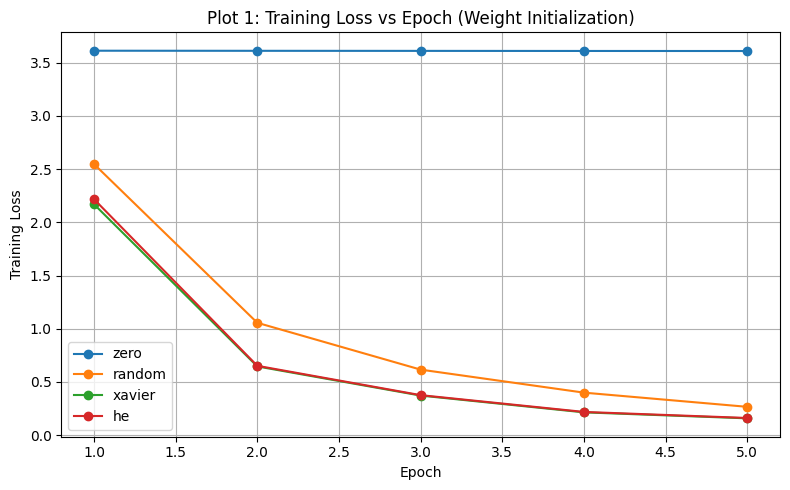

In [ ]:
# ==========================================
# Plot 1 : Training Loss vs Epoch (Weight Initialization)
# ==========================================

plt.figure(figsize=(8, 5))
for method in init_methods:
    plt.plot(range(1, init_epochs + 1), init_train_loss_history[method], marker="o", label=method)
plt.title("Plot 1: Training Loss vs Epoch (Weight Initialization)")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot1.png", dpi=300)
plt.show()

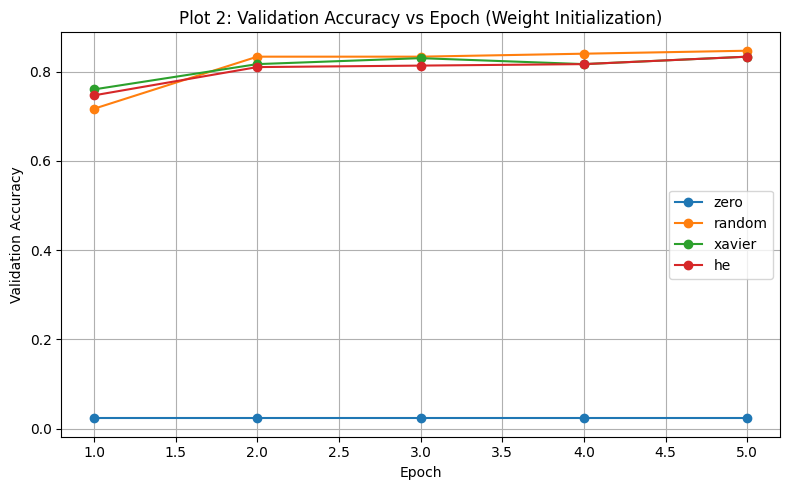

In [ ]:
# ==========================================
# Plot 2 : Validation Accuracy vs Epoch (Weight Initialization)
# ==========================================

plt.figure(figsize=(8, 5))
for method in init_methods:
    plt.plot(range(1, init_epochs + 1), init_val_acc_history[method], marker="o", label=method)
plt.title("Plot 2: Validation Accuracy vs Epoch (Weight Initialization)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot2.png", dpi=300)
plt.show()

### 8. Regularization, Overfitting and Batch Normalization Study (Sections 6-7)

In [ ]:
# ==========================================
# Task 5 : Regularization Comparison (No Reg / L2 / Dropout / BatchNorm)
# ==========================================

regularization_epochs = 6

reg_configs = {
    "No Regularization": dict(dropout_rate=0.0, use_batchnorm=False, weight_decay=0.0),
    "L2 Regularization": dict(dropout_rate=0.0, use_batchnorm=False, weight_decay=1e-4),
    "Dropout":           dict(dropout_rate=0.5, use_batchnorm=False, weight_decay=0.0),
    "Batch Normalization": dict(dropout_rate=0.0, use_batchnorm=True, weight_decay=0.0),
}

reg_train_acc_history = {}
reg_val_acc_history = {}
reg_train_loss_history = {}
reg_val_loss_history = {}

print("=" * 60)
print("REGULARIZATION STUDY")
print("=" * 60)

for name, cfg in reg_configs.items():
    print(f"\n--- Configuration: {name} ---")
    torch.manual_seed(seed)
    model = build_mobilenetv2(num_classes, pretrained=True, dropout_rate=cfg["dropout_rate"],
                               use_batchnorm=cfg["use_batchnorm"], freeze_base=True)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=0.001, weight_decay=cfg["weight_decay"])

    t_acc, v_acc, t_loss, v_loss = [], [], [], []

    for epoch in range(regularization_epochs):
        train_loss, train_acc = train_one_epoch(model, study_train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate_model(model, study_val_loader, criterion)

        t_acc.append(train_acc); v_acc.append(val_acc)
        t_loss.append(train_loss); v_loss.append(val_loss)

        print(f"Epoch [{epoch + 1}/{regularization_epochs}]  "
              f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
              f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    reg_train_acc_history[name] = t_acc
    reg_val_acc_history[name] = v_acc
    reg_train_loss_history[name] = t_loss
    reg_val_loss_history[name] = v_loss

    del model
    torch.cuda.empty_cache()

print("\nRegularization study completed.")

REGULARIZATION STUDY

--- Configuration: No Regularization ---
Epoch [1/6]  Train Acc: 0.3350  Val Acc: 0.7033  Train Loss: 2.8543  Val Loss: 1.7859
Epoch [2/6]  Train Acc: 0.7825  Val Acc: 0.8233  Train Loss: 1.1300  Val Loss: 0.8407
Epoch [3/6]  Train Acc: 0.8517  Val Acc: 0.8000  Train Loss: 0.6100  Val Loss: 0.6700
Epoch [4/6]  Train Acc: 0.9208  Val Acc: 0.8300  Train Loss: 0.3971  Val Loss: 0.5835
Epoch [5/6]  Train Acc: 0.9483  Val Acc: 0.8200  Train Loss: 0.2831  Val Loss: 0.5188
Epoch [6/6]  Train Acc: 0.9525  Val Acc: 0.8567  Train Loss: 0.2459  Val Loss: 0.4996

--- Configuration: L2 Regularization ---
Epoch [1/6]  Train Acc: 0.3392  Val Acc: 0.7033  Train Loss: 2.8537  Val Loss: 1.7852
Epoch [2/6]  Train Acc: 0.7858  Val Acc: 0.8200  Train Loss: 1.1293  Val Loss: 0.8412
Epoch [3/6]  Train Acc: 0.8533  Val Acc: 0.8033  Train Loss: 0.6104  Val Loss: 0.6710
Epoch [4/6]  Train Acc: 0.9200  Val Acc: 0.8333  Train Loss: 0.3983  Val Loss: 0.5862
Epoch [5/6]  Train Acc: 0.9475  Val

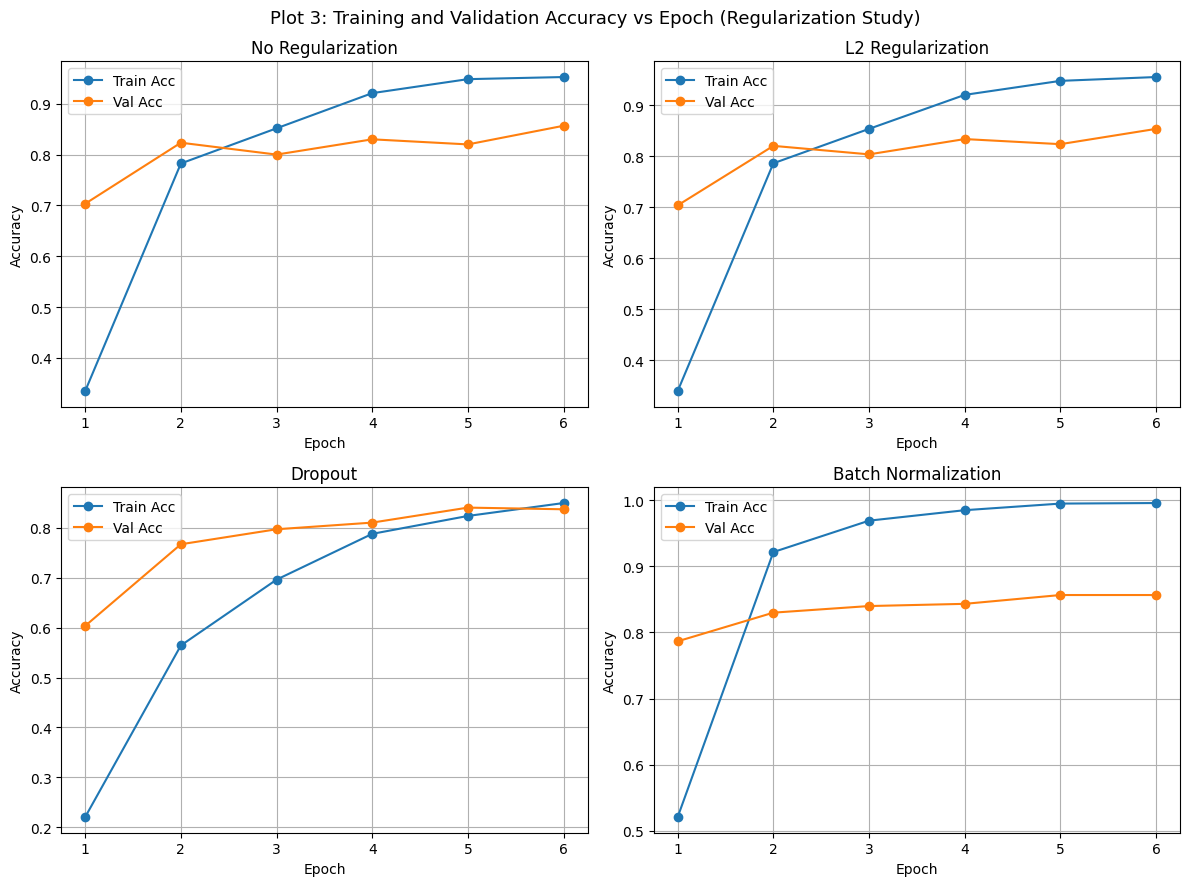

In [ ]:
# ==========================================
# Plot 3 : Training and Validation Accuracy vs Epoch (Regularization)
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, name in zip(axes, reg_configs.keys()):
    ax.plot(range(1, regularization_epochs + 1), reg_train_acc_history[name], marker="o", label="Train Acc")
    ax.plot(range(1, regularization_epochs + 1), reg_val_acc_history[name], marker="o", label="Val Acc")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)

plt.suptitle("Plot 3: Training and Validation Accuracy vs Epoch (Regularization Study)", fontsize=13)
plt.tight_layout()
plt.savefig("plot3.png", dpi=300)
plt.show()

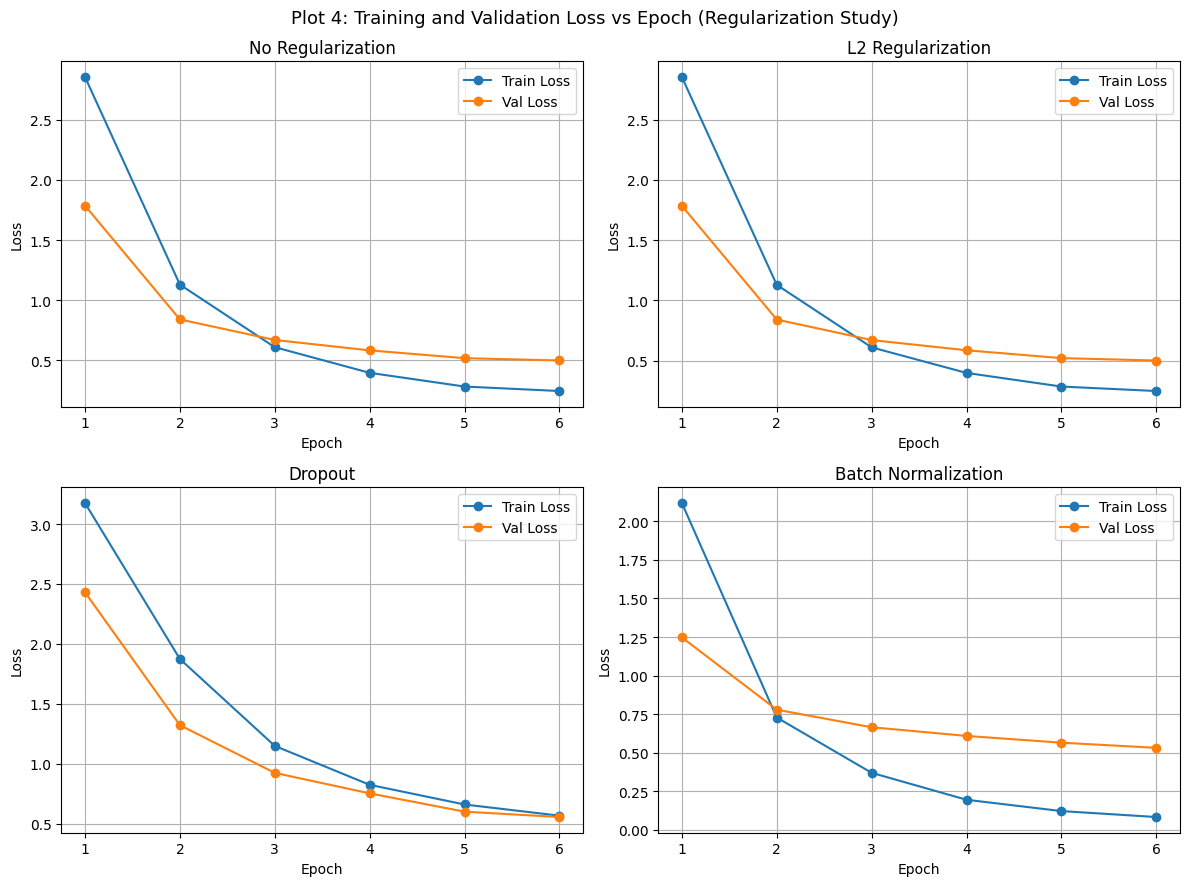

In [ ]:
# ==========================================
# Plot 4 : Training and Validation Loss vs Epoch (Regularization)
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, name in zip(axes, reg_configs.keys()):
    ax.plot(range(1, regularization_epochs + 1), reg_train_loss_history[name], marker="o", label="Train Loss")
    ax.plot(range(1, regularization_epochs + 1), reg_val_loss_history[name], marker="o", label="Val Loss")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

plt.suptitle("Plot 4: Training and Validation Loss vs Epoch (Regularization Study)", fontsize=13)
plt.tight_layout()
plt.savefig("plot4.png", dpi=300)
plt.show()

**Batch Normalization Numerical Example** (Section 7 of the lab manual): for themini-batch $x = [2, 4, 6, 8]$, the batch mean is $\mu_B = 5$ and the batch variance is$\sigma_B^2 = 5$, giving $\sqrt{\sigma_B^2} \approx 2.236$. The normalized activations arecomputed below directly, matching the manual's worked example.

In [ ]:
# ==========================================
# Task 5.1 : Batch Normalization Numerical Example
# ==========================================

x = np.array([2.0, 4.0, 6.0, 8.0])
epsilon = 1e-8

mu_B = x.mean()
var_B = x.var()  # population variance (ddof=0), matches the manual's formula
x_hat = (x - mu_B) / np.sqrt(var_B + epsilon)

gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta

print("=" * 60)
print("BATCH NORMALIZATION NUMERICAL EXAMPLE")
print("=" * 60)
print("x        :", x)
print(f"mu_B     : {mu_B:.4f}")
print(f"var_B    : {var_B:.4f}")
print("x_hat    :", np.round(x_hat, 3))
print("y (gamma=1, beta=0):", np.round(y, 3))

BATCH NORMALIZATION NUMERICAL EXAMPLE
x        : [2. 4. 6. 8.]
mu_B     : 5.0000
var_B    : 5.0000
x_hat    : [-1.342 -0.447  0.447  1.342]
y (gamma=1, beta=0): [-1.342 -0.447  0.447  1.342]


In [ ]:
# ==========================================
# Task 5.2 : With vs Without Batch Normalization
# ==========================================

bn_epochs = 6
bn_val_acc_history = {}

for name, use_bn in [("With BN", True), ("Without BN", False)]:
    print(f"\n--- {name} ---")
    torch.manual_seed(seed)
    model = build_mobilenetv2(num_classes, pretrained=True, dropout_rate=0.2,
                               use_batchnorm=use_bn, freeze_base=True)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    v_acc = []
    for epoch in range(bn_epochs):
        train_loss, train_acc = train_one_epoch(model, study_train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate_model(model, study_val_loader, criterion)
        v_acc.append(val_acc)
        print(f"Epoch [{epoch + 1}/{bn_epochs}]  Val Acc: {val_acc:.4f}")

    bn_val_acc_history[name] = v_acc
    del model
    torch.cuda.empty_cache()

print("\nBatch Normalization comparison completed.")


--- With BN ---
Epoch [1/6]  Val Acc: 0.7600
Epoch [2/6]  Val Acc: 0.8400
Epoch [3/6]  Val Acc: 0.8400
Epoch [4/6]  Val Acc: 0.8367
Epoch [5/6]  Val Acc: 0.8633
Epoch [6/6]  Val Acc: 0.8567

--- Without BN ---
Epoch [1/6]  Val Acc: 0.6833
Epoch [2/6]  Val Acc: 0.7867
Epoch [3/6]  Val Acc: 0.8000
Epoch [4/6]  Val Acc: 0.8333
Epoch [5/6]  Val Acc: 0.8167
Epoch [6/6]  Val Acc: 0.8333

Batch Normalization comparison completed.


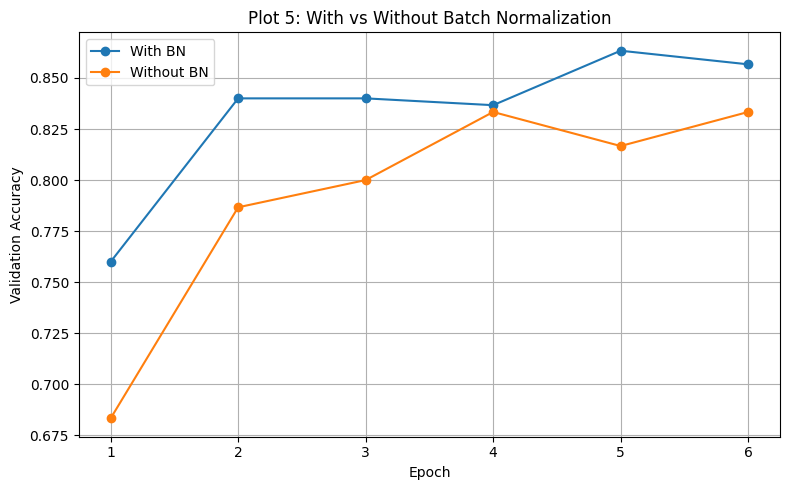

In [ ]:
# ==========================================
# Plot 5 : With vs Without Batch Normalization
# ==========================================

plt.figure(figsize=(8, 5))
for name in bn_val_acc_history:
    plt.plot(range(1, bn_epochs + 1), bn_val_acc_history[name], marker="o", label=name)
plt.title("Plot 5: With vs Without Batch Normalization")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot5.png", dpi=300)
plt.show()

### 9. Optimization Algorithms Study (Section 8)

In [ ]:
# ==========================================
# Task 6 : Optimizer Comparison (SGD / Momentum / RMSProp / Adam)
# ==========================================

optimizer_epochs = 6

def build_optimizer(name, params):
    if name == "SGD":
        return torch.optim.SGD(params, lr=0.01)
    elif name == "Momentum":
        return torch.optim.SGD(params, lr=0.01, momentum=0.9)
    elif name == "RMSProp":
        return torch.optim.RMSprop(params, lr=0.001)
    elif name == "Adam":
        return torch.optim.Adam(params, lr=0.001)

optimizer_names = ["SGD", "Momentum", "RMSProp", "Adam"]

opt_train_loss_history = {}
opt_val_acc_history = {}
opt_summary_rows = []

print("=" * 60)
print("OPTIMIZER STUDY")
print("=" * 60)

for opt_name in optimizer_names:
    print(f"\n--- Optimizer: {opt_name} ---")
    torch.manual_seed(seed)
    model = build_mobilenetv2(num_classes, pretrained=True, dropout_rate=0.2,
                               use_batchnorm=True, freeze_base=True)
    optimizer = build_optimizer(opt_name, filter(lambda p: p.requires_grad, model.parameters()))

    train_losses, val_accs = [], []
    best_val_acc = 0.0
    epoch_to_converge = optimizer_epochs

    start_time = time.time()
    for epoch in range(optimizer_epochs):
        train_loss, train_acc = train_one_epoch(model, study_train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate_model(model, study_val_loader, criterion)

        train_losses.append(train_loss)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epoch_to_converge = epoch + 1

        print(f"Epoch [{epoch + 1}/{optimizer_epochs}]  Train Loss: {train_loss:.4f}  Val Acc: {val_acc:.4f}")

    elapsed = time.time() - start_time

    opt_train_loss_history[opt_name] = train_losses
    opt_val_acc_history[opt_name] = val_accs

    opt_summary_rows.append({
        "Optimizer": opt_name,
        "Final Loss": train_losses[-1],
        "Best Val. Accuracy": best_val_acc,
        "Epoch to Converge": epoch_to_converge,
        "Time (s)": elapsed
    })

    del model
    torch.cuda.empty_cache()

optimizer_summary_df = pd.DataFrame(opt_summary_rows)
print("\n" + "=" * 60)
print("OPTIMIZER STUDY SUMMARY")
print("=" * 60)
print(optimizer_summary_df.to_string(index=False))

OPTIMIZER STUDY

--- Optimizer: SGD ---
Epoch [1/6]  Train Loss: 3.3141  Val Acc: 0.4533
Epoch [2/6]  Train Loss: 2.5518  Val Acc: 0.6267
Epoch [3/6]  Train Loss: 2.0700  Val Acc: 0.7033
Epoch [4/6]  Train Loss: 1.6883  Val Acc: 0.7300
Epoch [5/6]  Train Loss: 1.4418  Val Acc: 0.7500
Epoch [6/6]  Train Loss: 1.2570  Val Acc: 0.7767

--- Optimizer: Momentum ---
Epoch [1/6]  Train Loss: 2.3836  Val Acc: 0.7133
Epoch [2/6]  Train Loss: 0.7632  Val Acc: 0.8267
Epoch [3/6]  Train Loss: 0.4208  Val Acc: 0.8333
Epoch [4/6]  Train Loss: 0.2468  Val Acc: 0.8267
Epoch [5/6]  Train Loss: 0.1825  Val Acc: 0.8567
Epoch [6/6]  Train Loss: 0.1438  Val Acc: 0.8500

--- Optimizer: RMSProp ---
Epoch [1/6]  Train Loss: 1.5474  Val Acc: 0.8267
Epoch [2/6]  Train Loss: 0.4621  Val Acc: 0.8400
Epoch [3/6]  Train Loss: 0.2627  Val Acc: 0.8133
Epoch [4/6]  Train Loss: 0.1483  Val Acc: 0.8333
Epoch [5/6]  Train Loss: 0.1089  Val Acc: 0.8500
Epoch [6/6]  Train Loss: 0.0864  Val Acc: 0.8433

--- Optimizer: Adam 

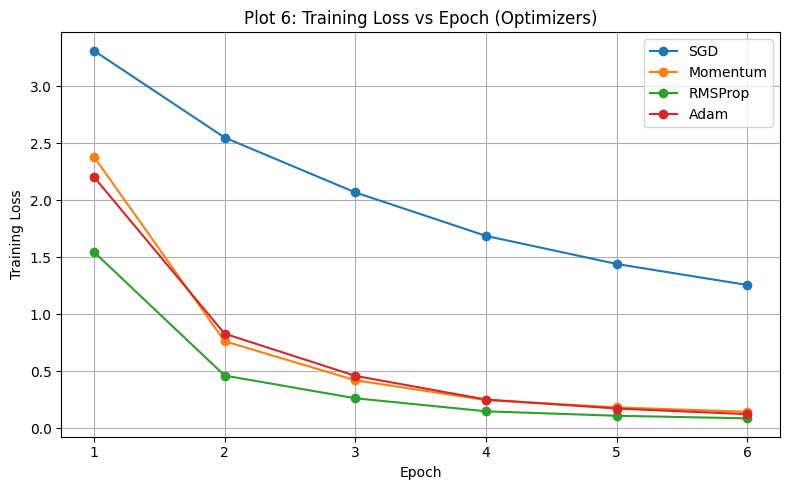

In [ ]:
# ==========================================
# Plot 6 : Training Loss vs Epoch for Different Optimizers
# ==========================================

plt.figure(figsize=(8, 5))
for opt_name in optimizer_names:
    plt.plot(range(1, optimizer_epochs + 1), opt_train_loss_history[opt_name], marker="o", label=opt_name)
plt.title("Plot 6: Training Loss vs Epoch (Optimizers)")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot6.png", dpi=300)
plt.show()

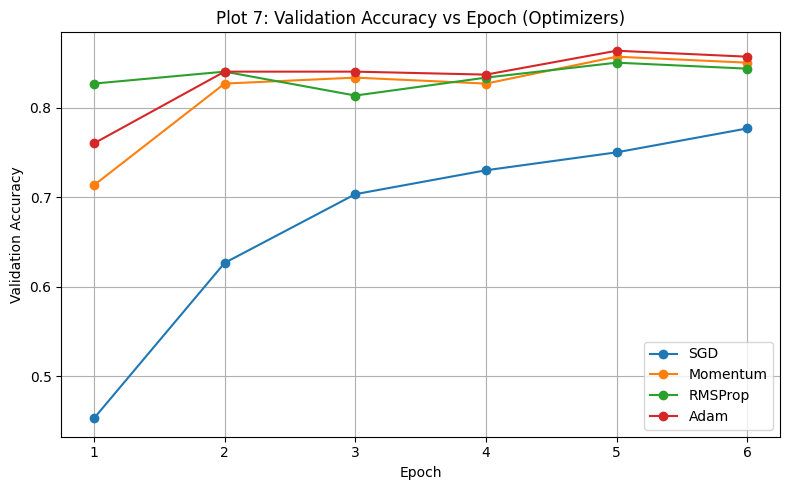

In [ ]:
# ==========================================
# Plot 7 : Validation Accuracy vs Epoch for Different Optimizers
# ==========================================

plt.figure(figsize=(8, 5))
for opt_name in optimizer_names:
    plt.plot(range(1, optimizer_epochs + 1), opt_val_acc_history[opt_name], marker="o", label=opt_name)
plt.title("Plot 7: Validation Accuracy vs Epoch (Optimizers)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot7.png", dpi=300)
plt.show()

### 10. CNN Hyperparameter Tuning (Section 9)

In [ ]:
# ==========================================
# Task 7 : Hyperparameter Study - Learning Rate, Batch Size, Dropout
# ==========================================

hp_epochs = 5

def quick_train_eval(lr=0.001, batch_size=32, dropout_rate=0.2, optimizer_name="Adam"):
    torch.manual_seed(seed)
    model = build_mobilenetv2(num_classes, pretrained=True, dropout_rate=dropout_rate,
                               use_batchnorm=True, freeze_base=True)

    loader = DataLoader(study_train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader_local = DataLoader(study_val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = torch.optim.Adam(params, lr=lr) if optimizer_name == "Adam" else torch.optim.SGD(params, lr=lr)

    val_acc = 0.0
    for epoch in range(hp_epochs):
        train_one_epoch(model, loader, optimizer, criterion)
        _, val_acc = evaluate_model(model, val_loader_local, criterion)

    del model
    torch.cuda.empty_cache()
    return val_acc


# ---- Learning Rate sweep ----
learning_rates = [0.001, 0.0001]
lr_val_accs = []
print("=" * 60)
print("LEARNING RATE SWEEP")
print("=" * 60)
for lr in learning_rates:
    acc = quick_train_eval(lr=lr)
    lr_val_accs.append(acc)
    print(f"Learning Rate = {lr}  ->  Val Acc = {acc:.4f}")

# ---- Batch Size sweep ----
batch_sizes = [16, 32, 64]
batch_val_accs = []
print("\n" + "=" * 60)
print("BATCH SIZE SWEEP")
print("=" * 60)
for bs in batch_sizes:
    acc = quick_train_eval(batch_size=bs)
    batch_val_accs.append(acc)
    print(f"Batch Size = {bs}  ->  Val Acc = {acc:.4f}")

# ---- Dropout Rate sweep ----
dropout_rates = [0.0, 0.25, 0.5]
dropout_val_accs = []
print("\n" + "=" * 60)
print("DROPOUT RATE SWEEP")
print("=" * 60)
for dr in dropout_rates:
    acc = quick_train_eval(dropout_rate=dr)
    dropout_val_accs.append(acc)
    print(f"Dropout Rate = {dr}  ->  Val Acc = {acc:.4f}")

LEARNING RATE SWEEP
Learning Rate = 0.001  ->  Val Acc = 0.8633
Learning Rate = 0.0001  ->  Val Acc = 0.7633

BATCH SIZE SWEEP
Batch Size = 16  ->  Val Acc = 0.8633
Batch Size = 32  ->  Val Acc = 0.8633
Batch Size = 64  ->  Val Acc = 0.8600

DROPOUT RATE SWEEP
Dropout Rate = 0.0  ->  Val Acc = 0.8567
Dropout Rate = 0.25  ->  Val Acc = 0.8600
Dropout Rate = 0.5  ->  Val Acc = 0.8667


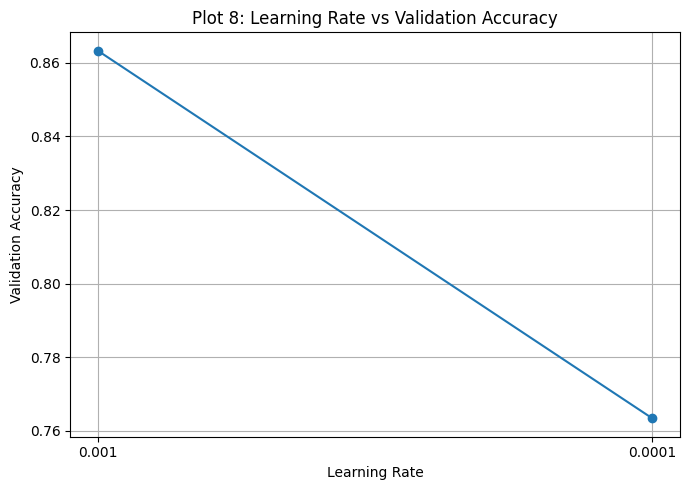

In [ ]:
# ==========================================
# Plot 8 : Learning Rate vs Validation Accuracy
# ==========================================

plt.figure(figsize=(7, 5))
plt.plot([str(lr) for lr in learning_rates], lr_val_accs, marker="o")
plt.title("Plot 8: Learning Rate vs Validation Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.savefig("plot8.png", dpi=300)
plt.show()

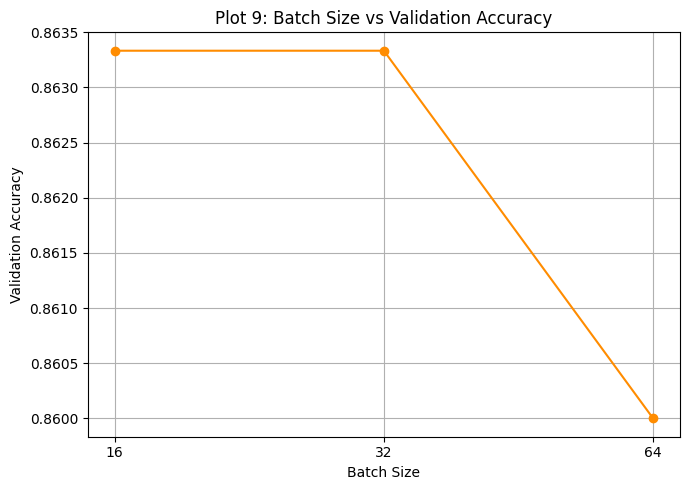

In [ ]:
# ==========================================
# Plot 9 : Batch Size vs Validation Accuracy
# ==========================================

plt.figure(figsize=(7, 5))
plt.plot([str(bs) for bs in batch_sizes], batch_val_accs, marker="o", color="darkorange")
plt.title("Plot 9: Batch Size vs Validation Accuracy")
plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.savefig("plot9.png", dpi=300)
plt.show()

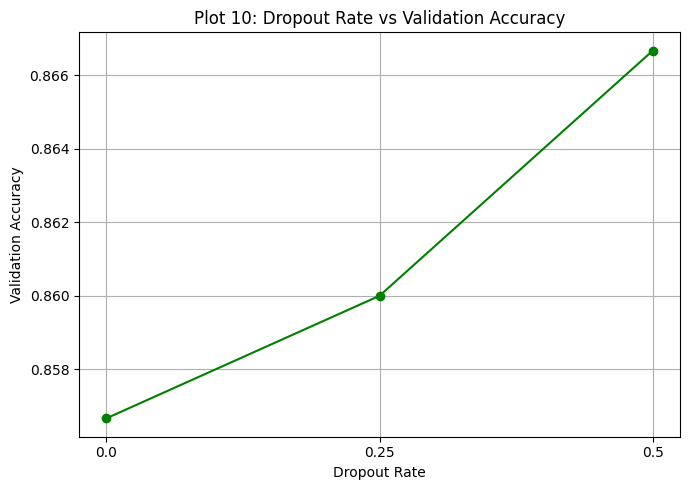

In [ ]:
# ==========================================
# Plot 10 : Dropout Rate vs Validation Accuracy
# ==========================================

plt.figure(figsize=(7, 5))
plt.plot([str(dr) for dr in dropout_rates], dropout_val_accs, marker="o", color="green")
plt.title("Plot 10: Dropout Rate vs Validation Accuracy")
plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.savefig("plot10.png", dpi=300)
plt.show()

### 11. Transfer Learning and Fine-Tuning (Section 10)

In [ ]:
# ==========================================
# Task 8 : Case A (Feature Extraction) vs Case B (Fine-Tuning)
# ==========================================

tl_epochs = 6

full_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
full_val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# ---- Case A: Feature Extraction (frozen base) ----
print("=" * 60)
print("CASE A : FEATURE EXTRACTION (FROZEN BASE)")
print("=" * 60)

torch.manual_seed(seed)
feature_extraction_model = build_mobilenetv2(num_classes, pretrained=True, dropout_rate=0.2,
                                              use_batchnorm=True, freeze_base=True)
fe_optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, feature_extraction_model.parameters()), lr=0.001)

fe_train_loss, fe_val_loss, fe_val_acc = [], [], []

fe_start = time.time()
for epoch in range(tl_epochs):
    train_loss, train_acc = train_one_epoch(feature_extraction_model, full_train_loader, fe_optimizer, criterion)
    val_loss, val_acc = evaluate_model(feature_extraction_model, full_val_loader, criterion)

    fe_train_loss.append(train_loss)
    fe_val_loss.append(val_loss)
    fe_val_acc.append(val_acc)

    print(f"Epoch [{epoch + 1}/{tl_epochs}]  Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

fe_time = time.time() - fe_start
print(f"\nFeature Extraction Training Time : {fe_time:.2f} seconds")

CASE A : FEATURE EXTRACTION (FROZEN BASE)
Epoch [1/6]  Train Loss: 1.4671  Train Acc: 0.6739  Val Loss: 0.6517  Val Acc: 0.8569
Epoch [2/6]  Train Loss: 0.5038  Train Acc: 0.8871  Val Loss: 0.4991  Val Acc: 0.8696
Epoch [3/6]  Train Loss: 0.2944  Train Acc: 0.9380  Val Loss: 0.4278  Val Acc: 0.8714
Epoch [4/6]  Train Loss: 0.1795  Train Acc: 0.9684  Val Loss: 0.4109  Val Acc: 0.8659
Epoch [5/6]  Train Loss: 0.1199  Train Acc: 0.9789  Val Loss: 0.4098  Val Acc: 0.8587
Epoch [6/6]  Train Loss: 0.0908  Train Acc: 0.9898  Val Loss: 0.4110  Val Acc: 0.8659

Feature Extraction Training Time : 110.96 seconds


In [ ]:
# ==========================================
# Task 8.1 : Case B - Fine-Tuning (Unfreeze Last Block, Small LR)
# ==========================================

print("=" * 60)
print("CASE B : FINE-TUNING (UNFREEZE LAST BLOCK)")
print("=" * 60)

fine_tune_model = copy.deepcopy(feature_extraction_model)

# Unfreeze the last inverted-residual block group of MobileNetV2's feature extractor
for param in fine_tune_model.features[-3:].parameters():
    param.requires_grad = True

ft_optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, fine_tune_model.parameters()), lr=1e-4)

ft_train_loss, ft_val_loss, ft_val_acc = [], [], []

ft_start = time.time()
for epoch in range(tl_epochs):
    train_loss, train_acc = train_one_epoch(fine_tune_model, full_train_loader, ft_optimizer, criterion)
    val_loss, val_acc = evaluate_model(fine_tune_model, full_val_loader, criterion)

    ft_train_loss.append(train_loss)
    ft_val_loss.append(val_loss)
    ft_val_acc.append(val_acc)

    print(f"Epoch [{epoch + 1}/{tl_epochs}]  Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

ft_time = time.time() - ft_start
print(f"\nFine-Tuning Training Time : {ft_time:.2f} seconds")

total_params_ft, trainable_params_ft = count_parameters(fine_tune_model)
print(f"Trainable Parameters After Unfreezing : {trainable_params_ft:,} / {total_params_ft:,}")

CASE B : FINE-TUNING (UNFREEZE LAST BLOCK)
Epoch [1/6]  Train Loss: 0.0645  Train Acc: 0.9882  Val Loss: 0.3898  Val Acc: 0.8696
Epoch [2/6]  Train Loss: 0.0425  Train Acc: 0.9971  Val Loss: 0.3686  Val Acc: 0.8659
Epoch [3/6]  Train Loss: 0.0312  Train Acc: 0.9981  Val Loss: 0.3936  Val Acc: 0.8696
Epoch [4/6]  Train Loss: 0.0249  Train Acc: 0.9990  Val Loss: 0.3614  Val Acc: 0.8696
Epoch [5/6]  Train Loss: 0.0200  Train Acc: 0.9994  Val Loss: 0.3571  Val Acc: 0.8768
Epoch [6/6]  Train Loss: 0.0187  Train Acc: 0.9990  Val Loss: 0.3698  Val Acc: 0.8750

Fine-Tuning Training Time : 111.03 seconds
Trainable Parameters After Unfreezing : 1,544,037 / 2,561,829


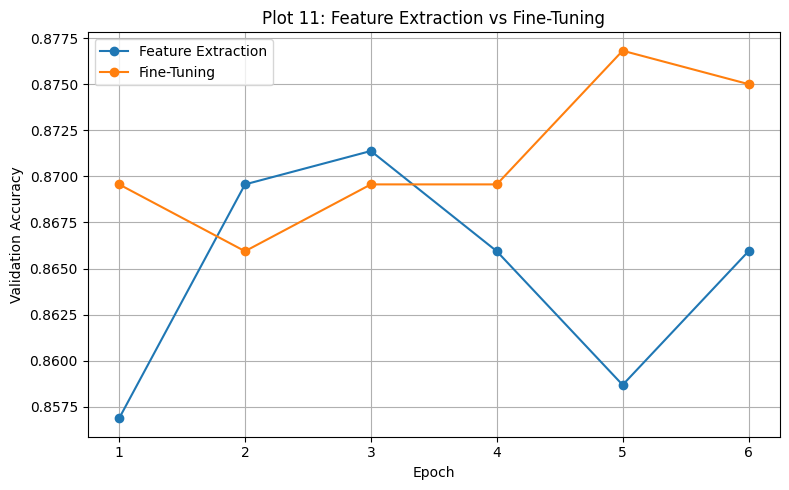

In [ ]:
# ==========================================
# Plot 11 : Feature Extraction vs Fine-Tuning (Validation Accuracy)
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(range(1, tl_epochs + 1), fe_val_acc, marker="o", label="Feature Extraction")
plt.plot(range(1, tl_epochs + 1), ft_val_acc, marker="o", label="Fine-Tuning")
plt.title("Plot 11: Feature Extraction vs Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot11.png", dpi=300)
plt.show()

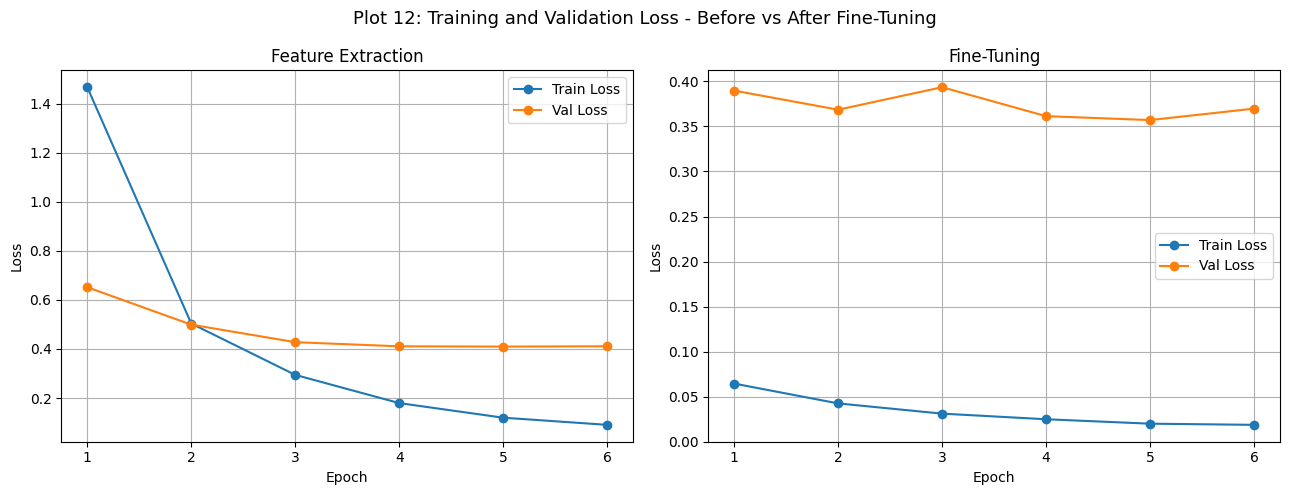

In [ ]:
# ==========================================
# Plot 12 : Training and Validation Loss (Feature Extraction vs Fine-Tuning)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, tl_epochs + 1), fe_train_loss, marker="o", label="Train Loss")
axes[0].plot(range(1, tl_epochs + 1), fe_val_loss, marker="o", label="Val Loss")
axes[0].set_title("Feature Extraction")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, tl_epochs + 1), ft_train_loss, marker="o", label="Train Loss")
axes[1].plot(range(1, tl_epochs + 1), ft_val_loss, marker="o", label="Val Loss")
axes[1].set_title("Fine-Tuning")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Plot 12: Training and Validation Loss - Before vs After Fine-Tuning", fontsize=13)
plt.tight_layout()
plt.savefig("plot12.png", dpi=300)
plt.show()

### 12. 5-Fold Cross-Validation (Section 11)

In [ ]:
# ==========================================
# Task 9 : Select Candidate Configurations for Cross-Validation
# ==========================================

cv_epochs = 4
k_folds = 5

# Candidate configurations informed by the studies above:
# C1 - Baseline frozen-backbone feature extraction
# C2 - Best regularization (Batch Normalization) setting
# C3 - Best optimizer (Adam) with tuned dropout
# C4 - Fine-tuning (partial unfreezing) at a reduced learning rate
cv_configs = {
    "C1_Baseline": dict(lr=0.001, dropout_rate=0.2, use_batchnorm=False, freeze_base=True, optimizer="Adam"),
    "C2_BatchNorm": dict(lr=0.001, dropout_rate=0.2, use_batchnorm=True, freeze_base=True, optimizer="Adam"),
    "C3_TunedDropout": dict(lr=0.001, dropout_rate=0.25, use_batchnorm=True, freeze_base=True, optimizer="Adam"),
    "C4_FineTune": dict(lr=1e-4, dropout_rate=0.2, use_batchnorm=True, freeze_base=False, optimizer="Adam"),
}

print("Cross-validation candidate configurations:")
for name, cfg in cv_configs.items():
    print(f"  {name}: {cfg}")

Cross-validation candidate configurations:
  C1_Baseline: {'lr': 0.001, 'dropout_rate': 0.2, 'use_batchnorm': False, 'freeze_base': True, 'optimizer': 'Adam'}
  C2_BatchNorm: {'lr': 0.001, 'dropout_rate': 0.2, 'use_batchnorm': True, 'freeze_base': True, 'optimizer': 'Adam'}
  C3_TunedDropout: {'lr': 0.001, 'dropout_rate': 0.25, 'use_batchnorm': True, 'freeze_base': True, 'optimizer': 'Adam'}
  C4_FineTune: {'lr': 0.0001, 'dropout_rate': 0.2, 'use_batchnorm': True, 'freeze_base': False, 'optimizer': 'Adam'}


In [ ]:
# ==========================================
# Task 9.1 : Run 5-Fold Cross-Validation for Each Configuration
# ==========================================

cv_data_size = len(train_dataset)
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=seed)
all_train_indices = list(range(cv_data_size))

cv_results = {name: [] for name in cv_configs}

print("=" * 60)
print("5-FOLD CROSS-VALIDATION")
print("=" * 60)

for config_name, cfg in cv_configs.items():
    print(f"\n### Configuration: {config_name} ###")

    for fold_index, (fold_train_idx, fold_val_idx) in enumerate(kfold.split(all_train_indices)):
        torch.manual_seed(seed + fold_index)

        fold_train_subset = Subset(train_dataset, fold_train_idx)
        fold_val_subset = Subset(train_dataset, fold_val_idx)

        fold_train_loader = DataLoader(fold_train_subset, batch_size=32, shuffle=True, num_workers=2)
        fold_val_loader = DataLoader(fold_val_subset, batch_size=32, shuffle=False, num_workers=2)

        model = build_mobilenetv2(num_classes, pretrained=True, dropout_rate=cfg["dropout_rate"],
                                   use_batchnorm=cfg["use_batchnorm"], freeze_base=cfg["freeze_base"])
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg["lr"])

        for epoch in range(cv_epochs):
            train_one_epoch(model, fold_train_loader, optimizer, criterion)

        _, fold_val_acc = evaluate_model(model, fold_val_loader, criterion)
        cv_results[config_name].append(fold_val_acc)

        print(f"  Fold {fold_index + 1}/{k_folds}  ->  Val Acc: {fold_val_acc:.4f}")

        del model
        torch.cuda.empty_cache()

print("\n5-fold cross-validation completed for all configurations.")

5-FOLD CROSS-VALIDATION

### Configuration: C1_Baseline ###
  Fold 1/5  ->  Val Acc: 0.8578
  Fold 2/5  ->  Val Acc: 0.8578
  Fold 3/5  ->  Val Acc: 0.8738
  Fold 4/5  ->  Val Acc: 0.8864
  Fold 5/5  ->  Val Acc: 0.8768

### Configuration: C2_BatchNorm ###
  Fold 1/5  ->  Val Acc: 0.8610
  Fold 2/5  ->  Val Acc: 0.8594
  Fold 3/5  ->  Val Acc: 0.8898
  Fold 4/5  ->  Val Acc: 0.8848
  Fold 5/5  ->  Val Acc: 0.8896

### Configuration: C3_TunedDropout ###
  Fold 1/5  ->  Val Acc: 0.8610
  Fold 2/5  ->  Val Acc: 0.8530
  Fold 3/5  ->  Val Acc: 0.8850
  Fold 4/5  ->  Val Acc: 0.8864
  Fold 5/5  ->  Val Acc: 0.8896

### Configuration: C4_FineTune ###
  Fold 1/5  ->  Val Acc: 0.8850
  Fold 2/5  ->  Val Acc: 0.8866
  Fold 3/5  ->  Val Acc: 0.9121
  Fold 4/5  ->  Val Acc: 0.9136
  Fold 5/5  ->  Val Acc: 0.9008

5-fold cross-validation completed for all configurations.


In [ ]:
# ==========================================
# Task 9.2 : Cross-Validation Summary Table
# ==========================================

cv_summary_rows = []
for config_name, accs in cv_results.items():
    accs = np.array(accs)
    row = {"Configuration": config_name}
    for i, acc in enumerate(accs):
        row[f"F{i+1}"] = acc
    row["Mean"] = accs.mean()
    row["SD"] = accs.std()
    cv_summary_rows.append(row)

cv_summary_df = pd.DataFrame(cv_summary_rows)

print("=" * 60)
print("5-FOLD CROSS-VALIDATION SUMMARY")
print("=" * 60)
print(cv_summary_df.to_string(index=False))

best_config_name = cv_summary_df.loc[cv_summary_df["Mean"].idxmax(), "Configuration"]
print(f"\nBest configuration by mean CV accuracy: {best_config_name}")

5-FOLD CROSS-VALIDATION SUMMARY
  Configuration       F1       F2       F3     F4     F5     Mean       SD
    C1_Baseline 0.857827 0.857827 0.873802 0.8864 0.8768 0.870531 0.011177
   C2_BatchNorm 0.861022 0.859425 0.889776 0.8848 0.8896 0.876925 0.013762
C3_TunedDropout 0.861022 0.853035 0.884984 0.8864 0.8896 0.875008 0.014971
    C4_FineTune 0.884984 0.886581 0.912141 0.9136 0.9008 0.899621 0.012148

Best configuration by mean CV accuracy: C4_FineTune


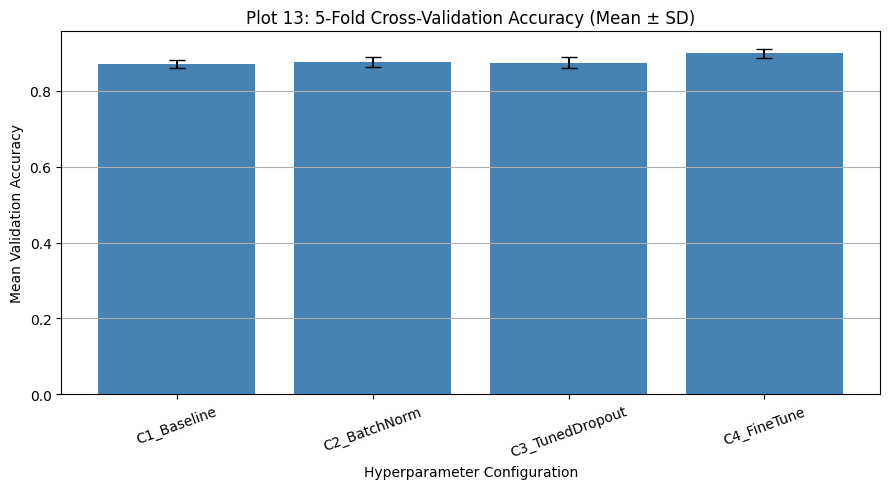

In [ ]:
# ==========================================
# Plot 13 : 5-Fold Cross-Validation Accuracy with Error Bars
# ==========================================

means = cv_summary_df["Mean"].values
sds = cv_summary_df["SD"].values
labels_cv = cv_summary_df["Configuration"].values

plt.figure(figsize=(9, 5))
plt.bar(labels_cv, means, yerr=sds, capsize=6, color="steelblue")
plt.title("Plot 13: 5-Fold Cross-Validation Accuracy (Mean ± SD)")
plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Mean Validation Accuracy")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig("plot13.png", dpi=300)
plt.show()

### 13. Final Model Evaluation on Test Set (Section 12)

In [ ]:
# ==========================================
# Task 10 : Retrain Best Configuration on Full Training Data
# ==========================================

best_cfg = cv_configs[best_config_name]
final_epochs = 8

print("=" * 60)
print(f"RETRAINING BEST CONFIGURATION: {best_config_name}")
print("=" * 60)
print("Configuration:", best_cfg)

torch.manual_seed(seed)
final_model = build_mobilenetv2(num_classes, pretrained=True, dropout_rate=best_cfg["dropout_rate"],
                                 use_batchnorm=best_cfg["use_batchnorm"], freeze_base=best_cfg["freeze_base"])
final_optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, final_model.parameters()), lr=best_cfg["lr"])

final_train_loss_history = []
final_val_acc_history = []

final_train_start = time.time()
for epoch in range(final_epochs):
    train_loss, train_acc = train_one_epoch(final_model, full_train_loader, final_optimizer, criterion)
    val_loss, val_acc = evaluate_model(final_model, full_val_loader, criterion)

    final_train_loss_history.append(train_loss)
    final_val_acc_history.append(val_acc)

    print(f"Epoch [{epoch + 1}/{final_epochs}]  Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

final_training_time = time.time() - final_train_start
print(f"\nFinal Model Training Time : {final_training_time:.2f} seconds")

total_params_final, trainable_params_final = count_parameters(final_model)
print(f"Total Parameters     : {total_params_final:,}")
print(f"Trainable Parameters : {trainable_params_final:,}")

RETRAINING BEST CONFIGURATION: C4_FineTune
Configuration: {'lr': 0.0001, 'dropout_rate': 0.2, 'use_batchnorm': True, 'freeze_base': False, 'optimizer': 'Adam'}
Epoch [1/8]  Train Loss: 2.6091  Train Acc: 0.4738  Val Loss: 1.6134  Val Acc: 0.7844
Epoch [2/8]  Train Loss: 1.3130  Train Acc: 0.8443  Val Loss: 1.0063  Val Acc: 0.8623
Epoch [3/8]  Train Loss: 0.8121  Train Acc: 0.9079  Val Loss: 0.7235  Val Acc: 0.8786
Epoch [4/8]  Train Loss: 0.5492  Train Acc: 0.9476  Val Loss: 0.5832  Val Acc: 0.8931
Epoch [5/8]  Train Loss: 0.3692  Train Acc: 0.9680  Val Loss: 0.4889  Val Acc: 0.9022
Epoch [6/8]  Train Loss: 0.2638  Train Acc: 0.9856  Val Loss: 0.4462  Val Acc: 0.9022
Epoch [7/8]  Train Loss: 0.1814  Train Acc: 0.9933  Val Loss: 0.4320  Val Acc: 0.8913
Epoch [8/8]  Train Loss: 0.1318  Train Acc: 0.9962  Val Loss: 0.3870  Val Acc: 0.9058

Final Model Training Time : 167.80 seconds
Total Parameters     : 2,561,829
Trainable Parameters : 2,561,829


In [55]:
# ==========================================
# Task 10.1 : Evaluate Final Model on the Untouched Test Set
# ==========================================

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

final_model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = final_model(images)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

test_accuracy = accuracy_score(all_labels, all_predictions)
test_precision = precision_score(all_labels, all_predictions, average="macro", zero_division=0)
test_recall = recall_score(all_labels, all_predictions, average="macro", zero_division=0)
test_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

mean_cv_accuracy = cv_summary_df.loc[cv_summary_df["Configuration"] == best_config_name, "Mean"].values[0]
cv_sd = cv_summary_df.loc[cv_summary_df["Configuration"] == best_config_name, "SD"].values[0]

print("=" * 60)
print("FINAL MODEL EVALUATION (TEST SET)")
print("=" * 60)
print(f"Best Configuration    : {best_config_name}")
print(f"Mean CV Accuracy      : {mean_cv_accuracy:.4f}")
print(f"CV Standard Deviation : {cv_sd:.4f}")
print(f"Test Accuracy         : {test_accuracy:.4f}")
print(f"Precision (macro)     : {test_precision:.4f}")
print(f"Recall (macro)        : {test_recall:.4f}")
print(f"F1-Score (macro)      : {test_f1:.4f}")
print(f"Training Time (s)     : {final_training_time:.2f}")
print(f"Number of Parameters  : {total_params_final:,}")

FINAL MODEL EVALUATION (TEST SET)
Best Configuration    : C4_FineTune
Mean CV Accuracy      : 0.8996
CV Standard Deviation : 0.0121
Test Accuracy         : 0.8923
Precision (macro)     : 0.8940
Recall (macro)        : 0.8917
F1-Score (macro)      : 0.8908
Training Time (s)     : 167.80
Number of Parameters  : 2,561,829


In [56]:
# ==========================================
# Task 10.2 : Classification Report
# ==========================================

print("=" * 60)
print("CLASSIFICATION REPORT (FINAL MODEL ON TEST SET)")
print("=" * 60)
print(classification_report(all_labels, all_predictions, target_names=class_names, zero_division=0))

CLASSIFICATION REPORT (FINAL MODEL ON TEST SET)
                            precision    recall  f1-score   support

                abyssinian       0.86      0.90      0.88        98
          american_bulldog       0.76      0.84      0.80       100
 american_pit_bull_terrier       0.76      0.63      0.69       100
              basset_hound       0.90      0.88      0.89       100
                    beagle       0.81      0.85      0.83       100
                    bengal       0.73      0.94      0.82       100
                    birman       0.77      0.92      0.84       100
                    bombay       0.81      0.98      0.89        88
                     boxer       0.88      0.89      0.88        99
         british_shorthair       0.91      0.74      0.82       100
                 chihuahua       0.91      0.81      0.86       100
              egyptian_mau       0.98      0.82      0.89        97
    english_cocker_spaniel       0.89      0.93      0.91       100

### 14. Confusion Matrix and Misclassified Images

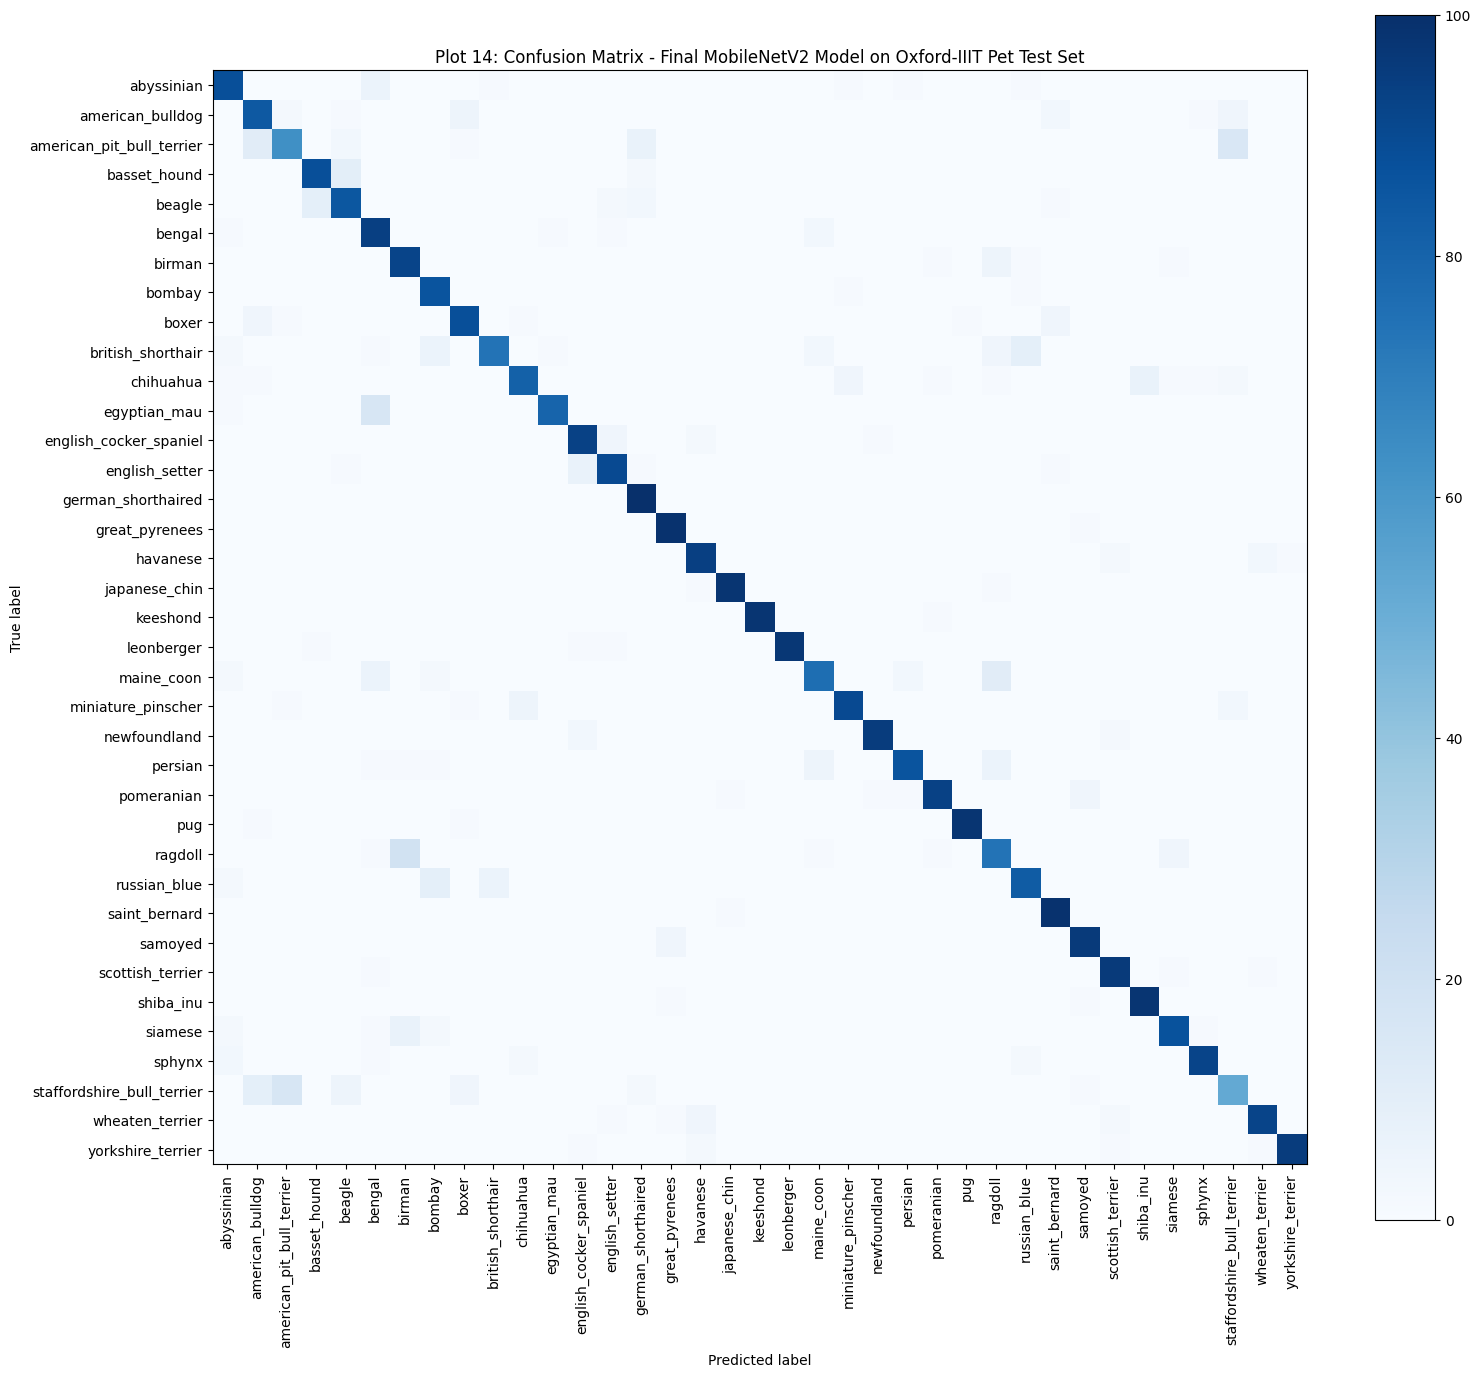

In [57]:
# ==========================================
# Plot 14 : Confusion Matrix
# ==========================================

conf_matrix = confusion_matrix(all_labels, all_predictions)

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=True, include_values=False)
plt.title("Plot 14: Confusion Matrix - Final MobileNetV2 Model on Oxford-IIIT Pet Test Set")
plt.tight_layout()
plt.savefig("plot14.png", dpi=300)
plt.show()

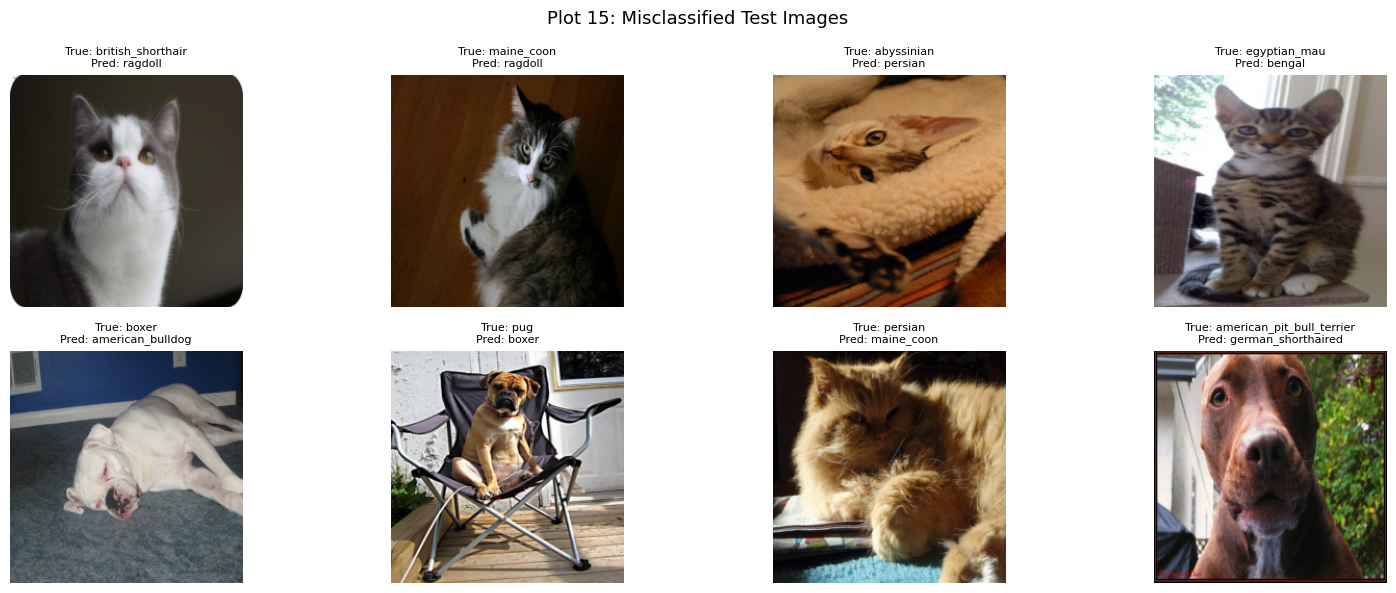

In [58]:
# ==========================================
# Plot 15 (Optional) : Misclassified Images
# ==========================================

misclassified_indices = np.where(all_predictions != all_labels)[0]
n_show = min(8, len(misclassified_indices))
sample_misclassified = np.random.choice(misclassified_indices, size=n_show, replace=False)

plt.figure(figsize=(16, 6))

for plot_index, data_index in enumerate(sample_misclassified):
    image, true_label = test_dataset[int(data_index)]
    predicted_label = all_predictions[data_index]
    image = denormalize(image)

    plt.subplot(2, 4, plot_index + 1)
    plt.imshow(image)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}", fontsize=8)
    plt.axis("off")

plt.suptitle("Plot 15: Misclassified Test Images", fontsize=13)
plt.tight_layout()
plt.savefig("plot15.png", dpi=300)
plt.show()

### 15. Overall Results Summary (Section 13)

In [59]:
# ==========================================
# Task 11 : Overall Results Summary Across All Studies
# ==========================================

best_init_method = max(init_val_acc_history, key=lambda k: init_val_acc_history[k][-1])
best_reg_name = max(reg_val_acc_history, key=lambda k: reg_val_acc_history[k][-1])
best_optimizer_name = optimizer_summary_df.loc[optimizer_summary_df["Best Val. Accuracy"].idxmax(), "Optimizer"]

overall_results_df = pd.DataFrame({
    "Configuration": [
        "Baseline (Frozen, No Reg)",
        f"Best Initialization ({best_init_method})",
        f"Best Regularization ({best_reg_name})",
        f"Best Optimizer ({best_optimizer_name})",
        f"Best Hyperparameters ({best_config_name})",
        "Fine-Tuned Model (Case B)"
    ],
    "CV / Val Accuracy": [
        reg_val_acc_history["No Regularization"][-1],
        init_val_acc_history[best_init_method][-1],
        reg_val_acc_history[best_reg_name][-1],
        max(opt_val_acc_history[best_optimizer_name]),
        mean_cv_accuracy,
        ft_val_acc[-1]
    ],
    "SD": [
        "-", "-", "-", "-", f"{cv_sd:.4f}", "-"
    ],
    "Test Accuracy": [
        "-", "-", "-", "-", f"{test_accuracy:.4f}", "-"
    ],
    "Training Time (s)": [
        "-", "-", "-", "-", f"{final_training_time:.2f}", f"{ft_time:.2f}"
    ]
})

print("=" * 60)
print("OVERALL RESULTS SUMMARY")
print("=" * 60)
print(overall_results_df.to_string(index=False))

OVERALL RESULTS SUMMARY
                          Configuration  CV / Val Accuracy     SD Test Accuracy Training Time (s)
              Baseline (Frozen, No Reg)           0.856667      -             -                 -
           Best Initialization (random)           0.846667      -             -                 -
Best Regularization (No Regularization)           0.856667      -             -                 -
                  Best Optimizer (Adam)           0.863333      -             -                 -
     Best Hyperparameters (C4_FineTune)           0.899621 0.0121        0.8923            167.80
              Fine-Tuned Model (Case B)           0.875000      -             -            111.03


### 16. Final Observations

In [60]:
# ==========================================
# Final Observations
# ==========================================

print("=" * 60)
print("FINAL OBSERVATIONS")
print("=" * 60)
print(f"1. Best weight initialization (final-epoch validation accuracy): {best_init_method}")
print(f"2. Best regularization strategy (final-epoch validation accuracy): {best_reg_name}")
print(f"3. Best optimizer (peak validation accuracy): {best_optimizer_name}")
print(f"4. Best cross-validated configuration: {best_config_name} "
      f"(Mean CV Accuracy = {mean_cv_accuracy:.4f} +/- {cv_sd:.4f})")
print(f"5. Final test accuracy of the retrained best configuration: {test_accuracy:.4f}")
print(f"6. Fine-tuning (Case B) reached a final validation accuracy of {ft_val_acc[-1]:.4f} "
      f"versus {fe_val_acc[-1]:.4f} for feature extraction alone (Case A).")

FINAL OBSERVATIONS
1. Best weight initialization (final-epoch validation accuracy): random
2. Best regularization strategy (final-epoch validation accuracy): No Regularization
3. Best optimizer (peak validation accuracy): Adam
4. Best cross-validated configuration: C4_FineTune (Mean CV Accuracy = 0.8996 +/- 0.0121)
5. Final test accuracy of the retrained best configuration: 0.8923
6. Fine-tuning (Case B) reached a final validation accuracy of 0.8750 versus 0.8659 for feature extraction alone (Case A).
